# Python Implementation

In [ ]:
!python --version

Python 3.10.15


In [31]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model  import Ridge,Lasso,RidgeCV, LassoCV, ElasticNet, ElasticNetCV, LogisticRegression
from sklearn.model_selection import train_test_split
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.metrics import accuracy_score, confusion_matrix, roc_curve, roc_auc_score
import matplotlib.pyplot as plt
import seaborn as sns

In [32]:
data = pd.read_csv("diabetes.csv")
data.head(7)

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1
5,5,116,74,0,0,25.6,0.201,30,0
6,3,78,50,32,88,31.0,0.248,26,1


In [33]:
data.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


In [34]:
data['BMI'] = data['BMI'].replace(0,data['BMI'].median())
data['BloodPressure'] = data['BloodPressure'].replace(0,data['BloodPressure'].median())
data['Glucose'] = data['Glucose'].replace(0,data['Glucose'].median())
data['Insulin'] = data['Insulin'].replace(0,data['Insulin'].median())
data['SkinThickness'] = data['SkinThickness'].replace(0,data['SkinThickness'].median())

In [35]:
data.head(7)

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,30.5,33.6,0.627,50,1
1,1,85,66,29,30.5,26.6,0.351,31,0
2,8,183,64,23,30.5,23.3,0.672,32,1
3,1,89,66,23,94.0,28.1,0.167,21,0
4,0,137,40,35,168.0,43.1,2.288,33,1
5,5,116,74,23,30.5,25.6,0.201,30,0
6,3,78,50,32,88.0,31.0,0.248,26,1


# Exploratory Data Analysis

<Axes: xlabel='Outcome', ylabel='count'>

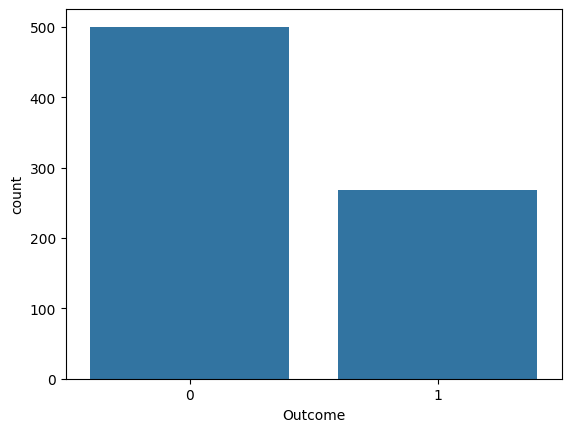

In [37]:
sns.countplot(x='Outcome', data=data)

<Axes: xlabel='Outcome', ylabel='Glucose'>

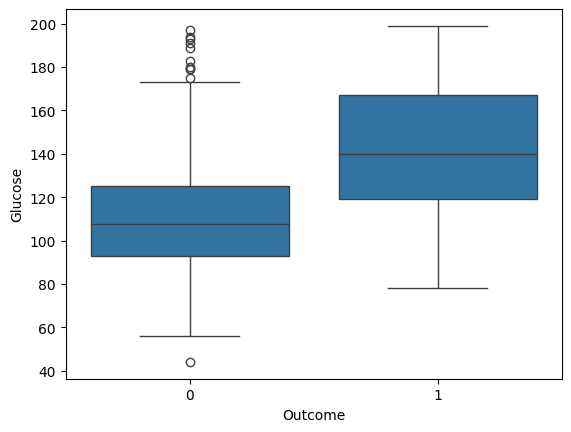

In [38]:
sns.boxplot(x='Outcome', y='Glucose', data=data)

<Axes: xlabel='Outcome', ylabel='BMI'>

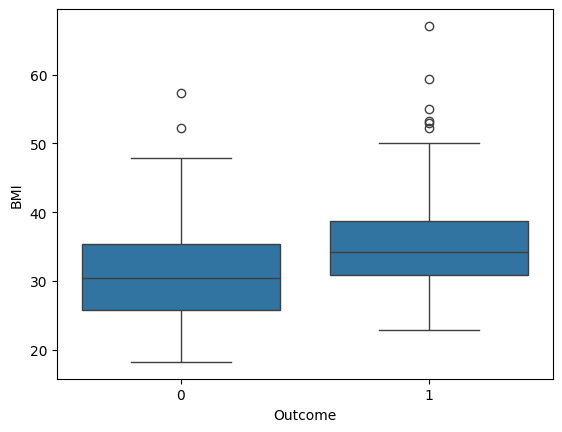

In [39]:
sns.boxplot(x='Outcome', y='BMI', data=data)

<Axes: xlabel='Age', ylabel='Count'>

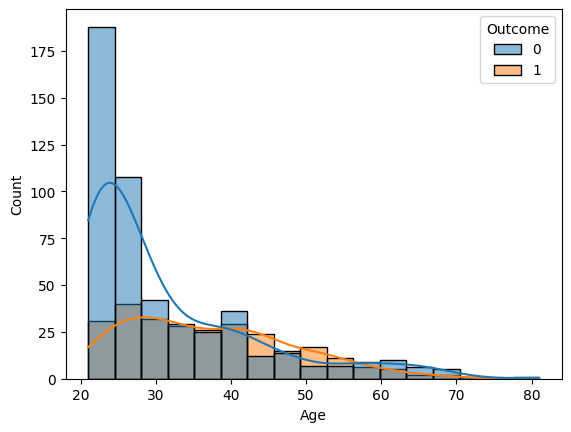

In [40]:
sns.histplot(data=data, x="Age", hue="Outcome", kde=True)

<Axes: >

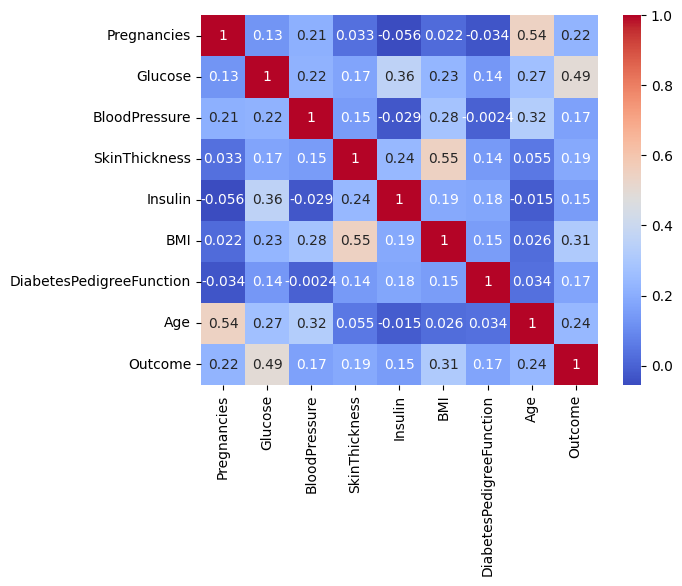

In [41]:
sns.heatmap(data.corr(), annot=True, cmap='coolwarm')

<Axes: xlabel='Glucose', ylabel='BMI'>

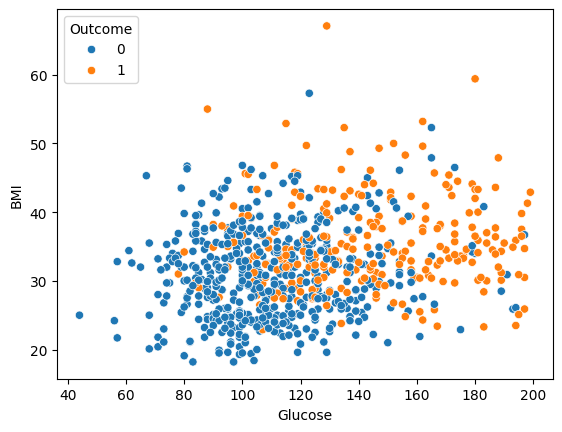

In [42]:
sns.scatterplot(x='Glucose', y='BMI', hue='Outcome', data=data)

<Axes: >

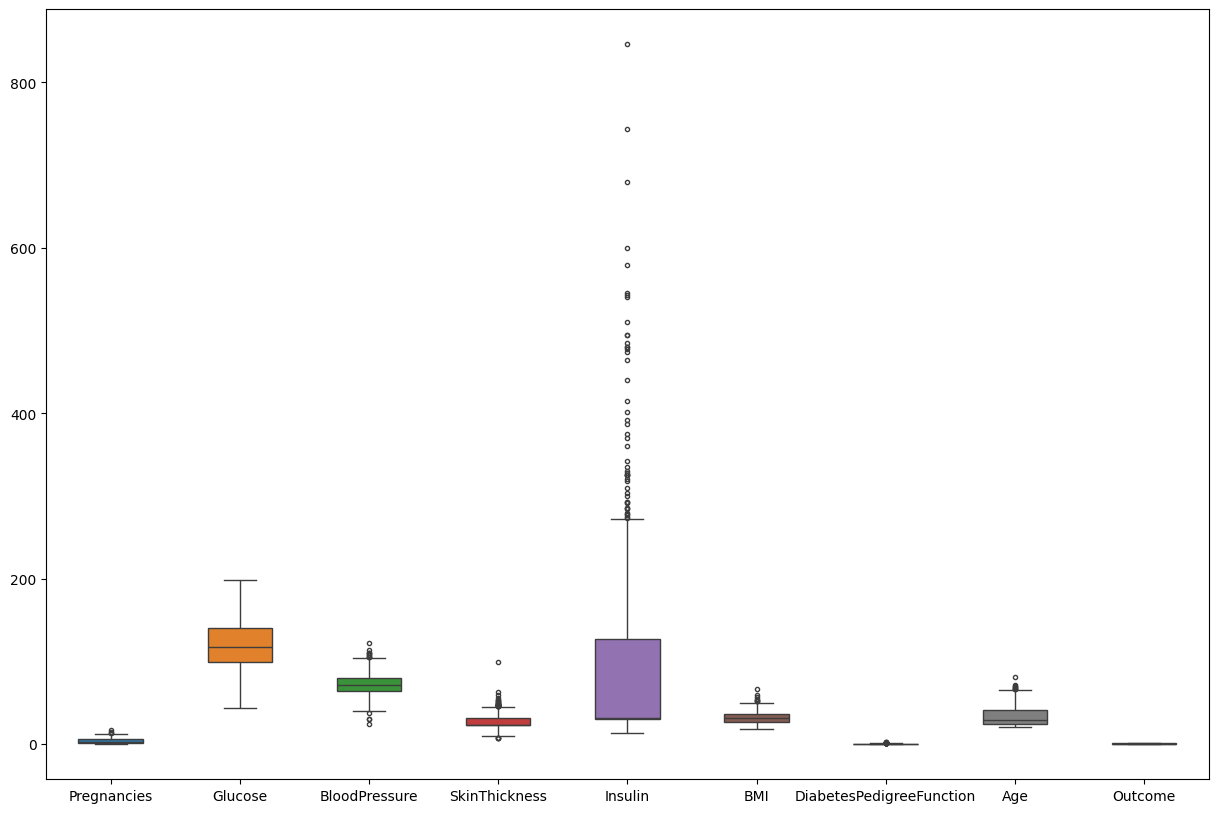

In [43]:
fig, ax = plt.subplots(figsize=(15,10))
sns.boxplot(data=data, width= 0.5,ax=ax,  fliersize=3)

#Removing Outliers

In [44]:
q = data['Pregnancies'].quantile(0.98)
# we are removing the top 2% data from the Pregnancies column
data_cleaned = data[data['Pregnancies']<q]
q = data_cleaned['BMI'].quantile(0.99)
# we are removing the top 1% data from the BMI column
data_cleaned  = data_cleaned[data_cleaned['BMI']<q]
q = data_cleaned['SkinThickness'].quantile(0.99)
# we are removing the top 1% data from the SkinThickness column
data_cleaned  = data_cleaned[data_cleaned['SkinThickness']<q]
q = data_cleaned['Insulin'].quantile(0.95)
# we are removing the top 5% data from the Insulin column
data_cleaned  = data_cleaned[data_cleaned['Insulin']<q]
q = data_cleaned['DiabetesPedigreeFunction'].quantile(0.99)
# we are removing the top 1% data from the DiabetesPedigreeFunction column
data_cleaned  = data_cleaned[data_cleaned['DiabetesPedigreeFunction']<q]
q = data_cleaned['Age'].quantile(0.99)
# we are removing the top 1% data from the Age column
data_cleaned  = data_cleaned[data_cleaned['Age']<q]

In [45]:
data_cleaned.head(7)

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,30.5,33.6,0.627,50,1
1,1,85,66,29,30.5,26.6,0.351,31,0
2,8,183,64,23,30.5,23.3,0.672,32,1
3,1,89,66,23,94.0,28.1,0.167,21,0
5,5,116,74,23,30.5,25.6,0.201,30,0
6,3,78,50,32,88.0,31.0,0.248,26,1
7,10,115,72,23,30.5,35.3,0.134,29,0


In [46]:
data_cleaned.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,674.000000,674.000000,674.000000,674.000000,674.000000,674.000000,674.000000,674.000000,674.000000
mean,3.602374,119.188427,72.132047,26.492582,75.680267,31.904303,0.447338,32.454006,0.327893
std,3.011478,29.273143,11.874232,8.103754,63.956394,6.384239,0.285170,10.964692,0.469794
min,0.000000,44.000000,24.000000,8.000000,15.000000,18.200000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,64.000000,23.000000,30.500000,27.300000,0.238000,24.000000,0.000000
50%,3.000000,114.500000,72.000000,23.000000,30.500000,32.000000,0.356000,29.000000,0.000000
75%,6.000000,136.000000,80.000000,32.000000,111.500000,35.800000,0.600000,39.000000,1.000000
max,11.000000,199.000000,122.000000,49.000000,291.000000,50.000000,1.476000,66.000000,1.000000


In [92]:
X = data_cleaned.drop(columns = ['Outcome'])
y = data_cleaned['Outcome']

In [93]:
scalar = StandardScaler()
X_scaled = scalar.fit_transform(X)

In [94]:
X_scaled

array([[ 0.79675391,  0.98496325, -0.01112877, ...,  0.26580405,
         0.63048454,  1.60141519],
       [-0.86479354, -1.16877843, -0.51679985, ..., -0.83146038,
        -0.33807867, -0.13270648],
       [ 1.46137289,  2.18148641, -0.68535688, ..., -1.34874219,
         0.78840246, -0.04143692],
       ...,
       [ 0.46444442,  0.06193111, -0.01112877, ..., -0.89416121,
        -0.71006309, -0.22397605],
       [-0.86479354,  0.23286298, -1.02247093, ..., -0.28282817,
        -0.34509724,  1.3276065 ],
       [-0.86479354, -0.89528742, -0.17968579, ..., -0.23580255,
        -0.464413  , -0.86286298]])

In [95]:
vif = pd.DataFrame()
vif["vif"] = [variance_inflation_factor(X_scaled,i) for i in range(X_scaled.shape[1])]
vif["Features"] = X.columns

#let's check the values
vif

,vif,Features
0,1.456545,Pregnancies
1,1.248455,Glucose
2,1.266151,BloodPressure
3,1.493086,SkinThickness
4,1.220668,Insulin
5,1.540574,BMI
6,1.051967,DiabetesPedigreeFunction
7,1.663956,Age


In [96]:
x_train,x_test,y_train,y_test = train_test_split(X_scaled,y, test_size= 0.25, random_state = 355)

In [119]:
log_reg = LogisticRegression()

log_reg.fit(x_train,y_train)

LogisticRegression()

In [120]:
y_prob = log_reg.predict_proba(x_test)[:,1]

In [98]:
import pickle
with open( 'modelForPrediction.pickle', 'wb') as f:
    pickle.dump(log_reg,f)

with open('standardScalar.pickle', 'wb') as f:
    pickle.dump(scalar,f)

In [122]:
y_pred = (y_prob > 0.3).astype(int)

In [129]:
accuracy = accuracy_score(y_test,y_pred)
accuracy

0.7633136094674556

In [123]:
# Confusion Matrix
tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()

In [130]:
# Breaking down the formula for Accuracy
Accuracy = (tp + tn) / (tp +fp + fn + tn)
Accuracy

np.float64(0.7633136094674556)

In [131]:
# Precison
Precision = tp/(tp+fp)
Precision

np.float64(0.5882352941176471)

In [132]:
# Recall
Recall = tp/(tp+fn)
Recall

np.float64(0.7692307692307693)

In [133]:
# F1 Score
F1_Score = 2*(Recall * Precision) / (Recall + Precision)
F1_Score

np.float64(0.6666666666666667)

In [134]:
# Area Under Curve
y_prob = log_reg.predict_proba(x_test)[:,1]
roc_auc_score(y_test, y_prob)

np.float64(0.8619329388560156)

# ROC

In [135]:
fpr, tpr, thresholds = roc_curve(y_test, y_pred)

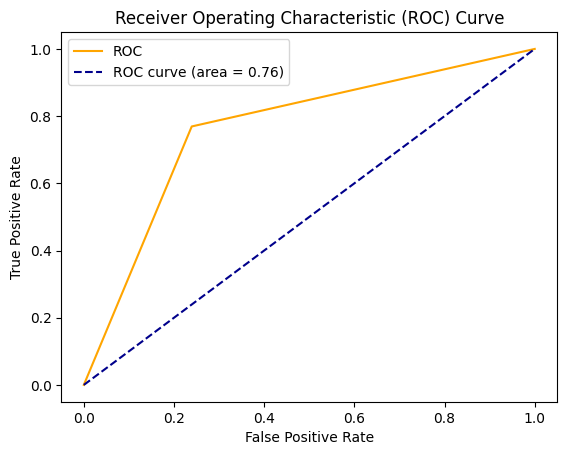

In [136]:
plt.plot(fpr, tpr, color='orange', label='ROC')
plt.plot([0, 1], [0, 1], color='darkblue', linestyle='--',label='ROC curve (area = %0.2f)' % auc)
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend()
plt.show()

In [137]:
data.columns

Index(['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin',
       'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome'],
      dtype='object')